<a href="https://colab.research.google.com/github/Tjandak/Jandak/blob/main/MojeMapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.4 MB/s eta 0:00:00


In [3]:
!pip install osmnx

In [4]:
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
#import networkx as nx

**MOJE MAPA**

Délka: 653 m,  uzlů: 8


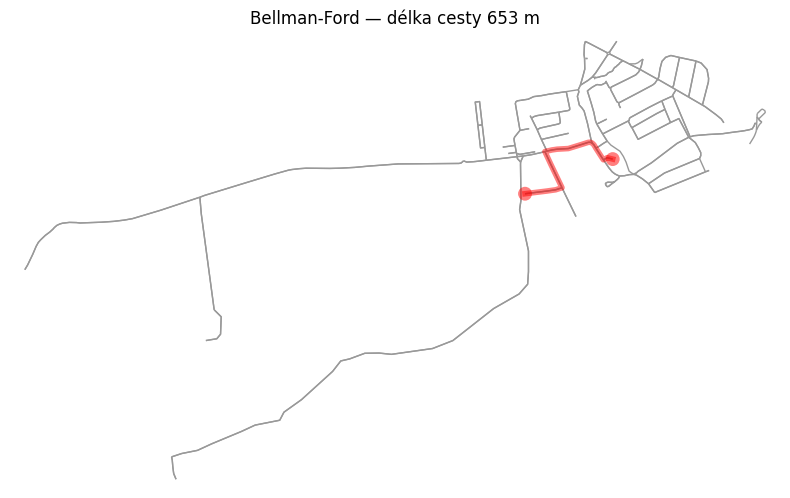

Cesta je dlouhá 652.71 metrů.


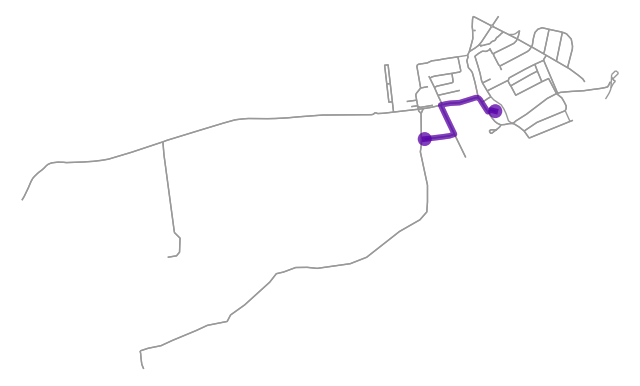

In [6]:
import warnings
warnings.filterwarnings("ignore")

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import folium

G = ox.graph_from_place("Drahělčice, Czech Republic", network_type="bike", simplify=True)

def bellman_ford(graf, start, cil):
    uzly = list(graf.nodes)
    hrany = [(u, v, d["length"]) for u, v, d in graf.edges(data=True)]

    dist = {u: float("inf") for u in uzly}
    dist[start] = 0
    odkud = {u: None for u in uzly}

    for _ in range(len(uzly) - 1):
        zmenilo_se = False
        for u, v, vaha in hrany:
            if dist[u] + vaha < dist[v]:
                dist[v] = dist[u] + vaha
                odkud[v] = u
                zmenilo_se = True
        if not zmenilo_se:
            break

    cesta, uzel = [], cil
    while uzel is not None:
        cesta.append(uzel)
        uzel = odkud[uzel]
    cesta.reverse()

    return dist[cil], cesta

start_gps = (50.0266, 14.1953)  # Drahělčice - střed obce
cil_gps   = (50.0311, 14.2051)  # Rudná

start = ox.nearest_nodes(G, X=start_gps[1], Y=start_gps[0])
cil   = ox.nearest_nodes(G, X=cil_gps[1],   Y=cil_gps[0])

delka, cesta = bellman_ford(G, start, cil)
print(f"Délka: {delka:.0f} m,  uzlů: {len(cesta)}")

fig, ax = ox.plot_graph_route(
    G, cesta,
    route_color="red", route_linewidth=4,
    node_size=0, bgcolor="white",
    show=False, close=False,
)
ax.set_title(f"Bellman-Ford — délka cesty {delka:.0f} m")
plt.tight_layout()
plt.savefig("bellman_ford_drahlecice.png", dpi=150, bbox_inches="tight")
plt.show()

cesta_delka = ox.shortest_path(G, start, cil, weight='length')
cesta_cas   = ox.shortest_path(G, start, cil, weight='travel_time')
delka_cesty = nx.shortest_path_length(G, start, cil, weight='length')
print(f'Cesta je dlouhá {delka_cesty:.2f} metrů.')

ox.plot_graph_routes(
    G,
    routes=[cesta_delka, cesta_cas],
    route_colors=["red", "blue"],
    route_linewidths=[4, 4],
    node_size=0,
    bgcolor="white",
)

body_delka = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in cesta_delka]
body_cas   = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in cesta_cas]

mid = body_delka[len(body_delka) // 2]
m = folium.Map(location=mid, zoom_start=15, width="70%")

folium.PolyLine(body_delka, color="red",  weight=4).add_to(m)
folium.PolyLine(body_cas,   color="blue", weight=4).add_to(m)

folium.Marker(body_cas[0], popup="Start - Drahělčice", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(body_cas[-1], popup="Cíl - Rudná",        icon=folium.Icon(color="red")).add_to(m)

m.save("cesty_drahlecice.html")
m